In [1]:
from google.colab import files

# آپلود فایل‌ها
uploaded = files.upload()

Saving plotting.py to plotting.py
Saving pokemon.csv to pokemon.csv


In [2]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt

# برای نمودارهای بهتر
plt.style.use('ggplot')
plt.rcParams.update({'font.size': 12})

np.random.seed(42)
print("✅ کتابخانه‌ها با موفقیت لود شدند!")

✅ کتابخانه‌ها با موفقیت لود شدند!


## 📊 Load Data



In [3]:
# خواندن داده
df = (pd.read_csv("pokemon.csv", usecols=['name', 'defense', 'attack'], index_col=0)
        .head(10)
        .sort_values(by='defense')
        .reset_index()
     )

x = df['defense']  # ویژگی ورودی (دفاع)
y = df['attack']   # خروجی (حمله)

print("📊 داده‌های 10 پوکمون اول:")
df

📊 داده‌های 10 پوکمون اول:


,name,attack,defense
0,Caterpie,30,35
1,Charmander,52,43
2,Bulbasaur,49,49
3,Charmeleon,64,58
4,Ivysaur,62,63
5,Squirtle,48,65
6,Charizard,104,78
7,Wartortle,63,80
8,Blastoise,103,120
9,Venusaur,100,123


## 📈 Plot Data

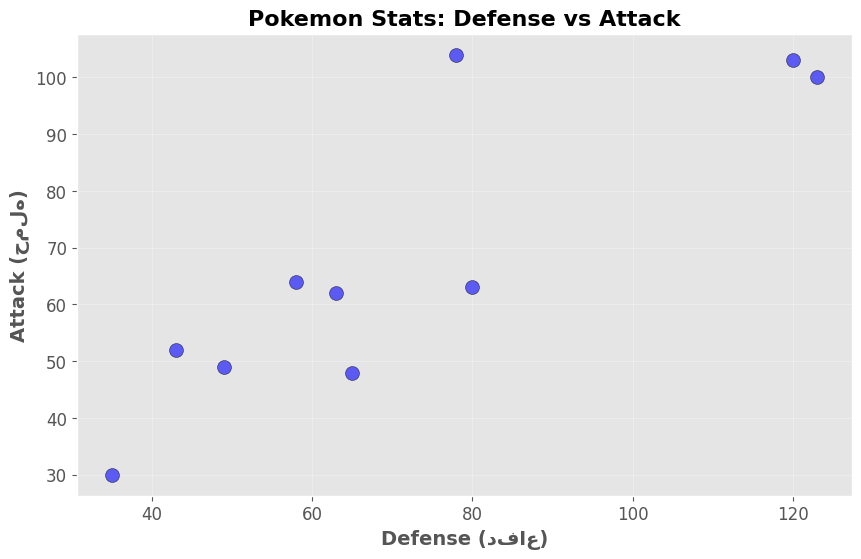

 هدف: پیدا کردن بهترین خطی که از روی این نقاط عبور کند!


In [4]:
# رسم داده‌ها
plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='blue', s=100, alpha=0.6, edgecolors='black')
plt.xlabel('Defense (دفاع)', fontsize=14, fontweight='bold')
plt.ylabel('Attack (حمله)', fontsize=14, fontweight='bold')
plt.title('Pokemon Stats: Defense vs Attack', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

print(" هدف: پیدا کردن بهترین خطی که از روی این نقاط عبور کند!")

## 3.1. Visually and Randomly (تست دستی)

    w0     w1          MSE
     0    0.5      1216.75
     0    0.8       265.32
     0    1.0       221.50
     0    1.2       650.04
     0    1.5      2178.55
✅ بهترین: w0=0, w1=1.0  →  MSE=221.50


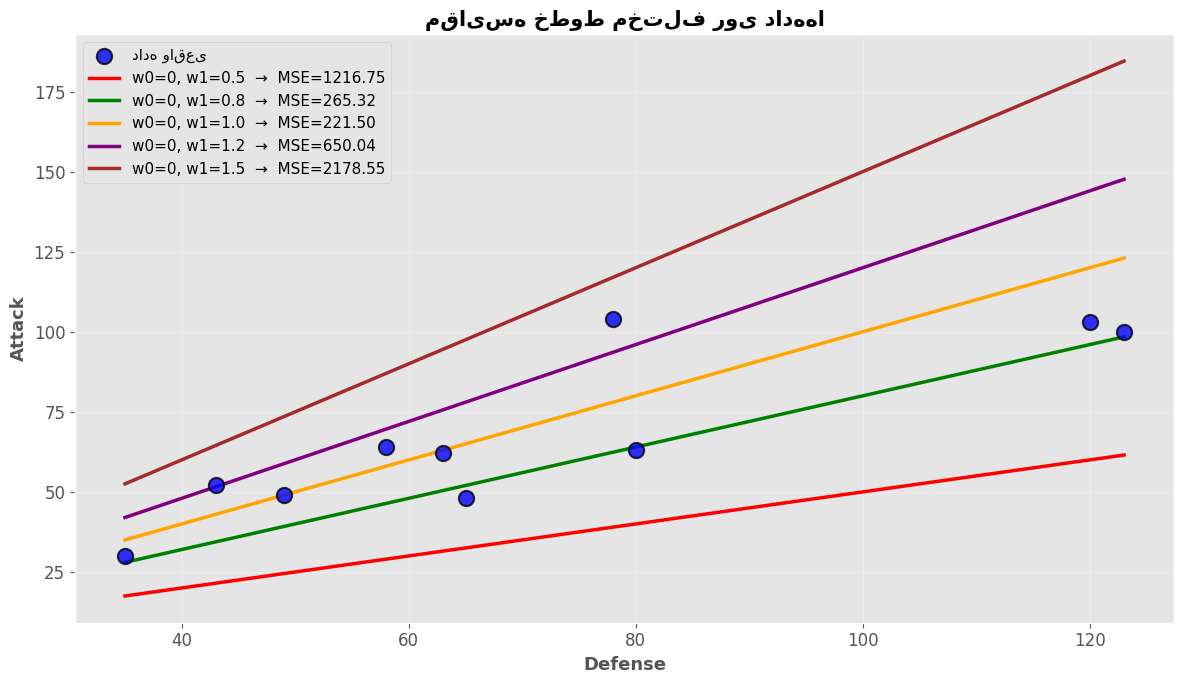

In [5]:

# تست دستی مقادیر مختلف w0 و w1


test_values = [
    # (w0,  w1)     ← هر خط یه ترکیب
    (0,   0.5),
    (0,   0.8),
    (0,   1.0),
    (0,   1.2),
    (0,   1.5),
]
# ------------------------------------------

def mean_squared_error(y, y_hat):
    return np.mean((y - y_hat) ** 2)

# رنگ‌های مختلف برای هر خط
colors = ['red', 'green', 'orange', 'purple', 'brown']

# ---- نمودار ----
plt.figure(figsize=(12, 7))

# نقاط داده
plt.scatter(x, y, color='blue', s=120, alpha=0.8,
            edgecolors='black', linewidth=1.5,
            label='داده واقعی', zorder=5)

best_mse = float('inf')
best_params = None

print("=" * 50)
print(f"{'w0':>6} {'w1':>6}   {'MSE':>10}")
print("=" * 50)

for i, (w0, w1) in enumerate(test_values):
    y_hat = w0 + w1 * x
    error = mean_squared_error(y, y_hat)

    # رسم خط
    plt.plot(x, y_hat,
             color=colors[i % len(colors)],
             linewidth=2.5,
             label=f'w0={w0}, w1={w1}  →  MSE={error:.2f}')

    print(f"{w0:>6} {w1:>6}   {error:>10.2f}")

    if error < best_mse:
        best_mse = error
        best_params = (w0, w1)

print("=" * 50)
print(f"✅ بهترین: w0={best_params[0]}, w1={best_params[1]}  →  MSE={best_mse:.2f}")

# تنظیمات نمودار
plt.xlabel('Defense', fontsize=13, fontweight='bold')
plt.ylabel('Attack', fontsize=13, fontweight='bold')
plt.title('مقایسه خطوط مختلف روی داده‌ها', fontsize=15, fontweight='bold')
plt.legend(fontsize=11, loc='best', framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



## 3.2. Grid Search (جستجوی شبکه‌ای)



In [6]:
# تابع محاسبه خطا (MSE)
def mean_squared_error(y, y_hat):
    """
    محاسبه میانگین مجذور خطا
    MSE = (1/n) * sum((y_pred - y_actual)^2)
    """
    return np.mean((y - y_hat)**2)

print("✅ تابع MSE آماده شد!")

✅ تابع MSE آماده شد!


In [7]:
# تست مقادیر مختلف w1 از -5 تا 5
w0 = 0
slopes = np.arange(-5, 5.5, 0.5)  # از -5 تا 5 با گام 0.5

# لیست خطاها
mse_list = []

for w1 in slopes:
    y_hat = w0 + w1 * x
    mse = mean_squared_error(y, y_hat)
    mse_list.append(mse)

# ساخت DataFrame
mse_df = pd.DataFrame({
    "slope": slopes,
    "MSE": mse_list
})

print("📊 نتایج Grid Search:")
print(mse_df)
print(f"\n🎯 بهترین w1: {mse_df.loc[mse_df['MSE'].idxmin(), 'slope']}")
print(f"🎯 کمترین MSE: {mse_df['MSE'].min():.2f}")

📊 نتایج Grid Search:
    slope        MSE
0    -5.0  207016.30
1    -4.5  173545.75
2    -4.0  143027.50
3    -3.5  115461.55
4    -3.0   90847.90
5    -2.5   69186.55
6    -2.0   50477.50
7    -1.5   34720.75
8    -1.0   21916.30
9    -0.5   12064.15
10    0.0    5164.30
11    0.5    1216.75
12    1.0     221.50
13    1.5    2178.55
14    2.0    7087.90
15    2.5   14949.55
16    3.0   25763.50
17    3.5   39529.75
18    4.0   56248.30
19    4.5   75919.15
20    5.0   98542.30

🎯 بهترین w1: 1.0
🎯 کمترین MSE: 221.50


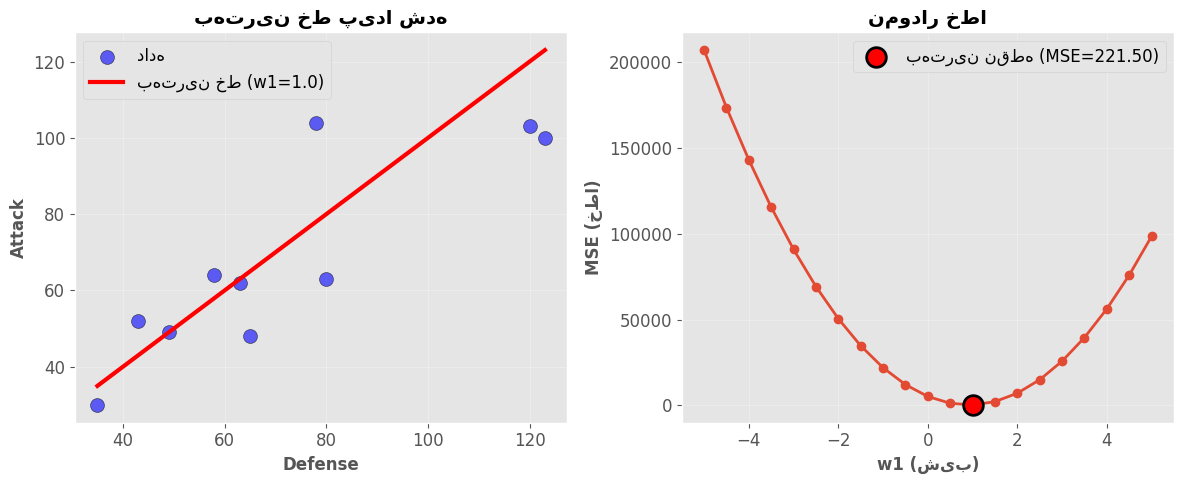

In [8]:
# رسم نمودار MSE
plt.figure(figsize=(12, 5))

# نمودار 1: خط
plt.subplot(1, 2, 1)
best_w1 = mse_df.loc[mse_df['MSE'].idxmin(), 'slope']
best_y_hat = w0 + best_w1 * x
plt.scatter(x, y, color='blue', s=100, alpha=0.6, edgecolors='black', label='داده')
plt.plot(x, best_y_hat, color='red', linewidth=3, label=f'بهترین خط (w1={best_w1})')
plt.xlabel('Defense', fontsize=12, fontweight='bold')
plt.ylabel('Attack', fontsize=12, fontweight='bold')
plt.title('بهترین خط پیدا شده', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# نمودار 2: MSE
plt.subplot(1, 2, 2)
plt.plot(mse_df['slope'], mse_df['MSE'], marker='o', linewidth=2, markersize=6)
plt.scatter([best_w1], [mse_df['MSE'].min()], color='red', s=200, zorder=5,
            label=f'بهترین نقطه (MSE={mse_df["MSE"].min():.2f})', edgecolors='black', linewidth=2)
plt.xlabel('w1 (شیب)', fontsize=12, fontweight='bold')
plt.ylabel('MSE (خطا)', fontsize=12, fontweight='bold')
plt.title('نمودار خطا', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



---
#  Section 4: Gradient Descent Algorithm


## 4.1. Gradient Descent with One Parameter

In [9]:
# تابع محاسبه گرادیان (مشتق)
def gradient(x, y, w):
    """
    محاسبه گرادیان تابع MSE نسبت به w

    فرمول: gradient = (2/n) * sum(x * (w*x - y))
    """
    n = len(x)
    y_pred = w * x  # پیش‌بینی
    grad = (2/n) * np.sum(x * (y_pred - y))
    return grad

# تست
test_grad = gradient(x, y, w=0.5)
print(f"✅ گرادیان در w=0.5: {test_grad:.2f}")

✅ گرادیان در w=0.5: -4942.80


In [10]:
# تابع Gradient Descent
def gradient_descent(x, y, w_init, alpha, epsilon=2e-4, max_iterations=5000, print_progress=10):
    """
    الگوریتم گرادیان کاهشی

    Args:
        x: داده ورودی
        y: داده خروجی
        w_init: مقدار اولیه w
        alpha: نرخ یادگیری (learning rate)
        epsilon: حد توقف
        max_iterations: حداکثر تکرار
        print_progress: نمایش پیشرفت

    Returns:
        w_final: بهترین مقدار w
        history: تاریخچه w و MSE
    """
    w = w_init
    history = {'w': [w], 'mse': [mean_squared_error(y, w*x)]}

    for i in range(max_iterations):
        # محاسبه گرادیان
        grad = gradient(x, y, w)

        # به‌روزرسانی w
        w_new = w - alpha * grad

        # ذخیره تاریخچه
        mse = mean_squared_error(y, w_new * x)
        history['w'].append(w_new)
        history['mse'].append(mse)

        # نمایش پیشرفت
        if (i+1) % print_progress == 0:
            print(f"Iteration {i+1}: w={w_new:.4f}, MSE={mse:.2f}, gradient={grad:.4f}")

        # بررسی شرط توقف
        if abs(w_new - w) < epsilon:
            print(f"\n✅ همگرا شد در iteration {i+1}!")
            break

        w = w_new

    return w, history

print("✅ تابع Gradient Descent آماده شد!")

✅ تابع Gradient Descent آماده شد!


In [15]:
# تست مقادیر مختلف
alphas_test = [0.1, 0.01, 0.001, 0.0001]

for alpha in alphas_test:
    print(f"\n{'='*50}")
    print(f"Testing alpha = {alpha}")
    print('='*50)

    try:
        w_final, history = gradient_descent(x, y, w_init=0.5, alpha=alpha,
                                           print_progress=100, max_iterations=1000)

        if np.isnan(w_final):
            print(f"❌ alpha={alpha} → NaN شد! (خیلی بزرگه)")
        else:
            print(f"✅ alpha={alpha} → w={w_final:.4f}, iterations={len(history['w'])-1}")
    except:
        print(f"❌ alpha={alpha} → خطا!")


Testing alpha = 0.1
Iteration 100: w=-inf, MSE=inf, gradient=inf
Iteration 200: w=nan, MSE=nan, gradient=0.0000
Iteration 300: w=nan, MSE=nan, gradient=0.0000
Iteration 400: w=nan, MSE=nan, gradient=0.0000


/tmp/ipython-input-1621539130.py:27: RuntimeWarning: invalid value encountered in scalar subtract
  w_new = w - alpha * grad


Iteration 500: w=nan, MSE=nan, gradient=0.0000
Iteration 600: w=nan, MSE=nan, gradient=0.0000
Iteration 700: w=nan, MSE=nan, gradient=0.0000
Iteration 800: w=nan, MSE=nan, gradient=0.0000
Iteration 900: w=nan, MSE=nan, gradient=0.0000
Iteration 1000: w=nan, MSE=nan, gradient=0.0000
❌ alpha=0.1 → NaN شد! (خیلی بزرگه)

Testing alpha = 0.01
Iteration 100: w=-298177567166137769277642416578325526454119533705835994760388151632542433618029371737055737609340265826728079550840738421672219797780564002285145900092780641507073112468615015531844453597022028482762504142848.0000, MSE=inf, gradient=30072409098643410499881415338738782533629182015555560285179927670159709125548109966188729611018144735798447406098953963497818618674860647834312238386814227336891167855131153700547823868688265828741285542887424.0000
Iteration 200: w=nan, MSE=nan, gradient=0.0000
Iteration 300: w=nan, MSE=nan, gradient=0.0000
Iteration 400: w=nan, MSE=nan, gradient=0.0000
Iteration 500: w=nan, MSE=nan, gradient=0.0000
Iterati

In [16]:
# اجرای Gradient Descent
print(" شروع Gradient Descent...\n")

w_init = 0.5       # مقدار اولیه
alpha = 0.0001

w_final, history = gradient_descent(x, y, w_init, alpha, print_progress=50)

print(f"\n نتیجه نهایی:")
print(f"   w = {w_final:.4f}")
print(f"   MSE = {history['mse'][-1]:.2f}")
print(f"   تعداد iteration: {len(history['w'])-1}")

 شروع Gradient Descent...


✅ همگرا شد در iteration 6!

 نتیجه نهایی:
   w = 0.9186
   MSE = 182.33
   تعداد iteration: 6


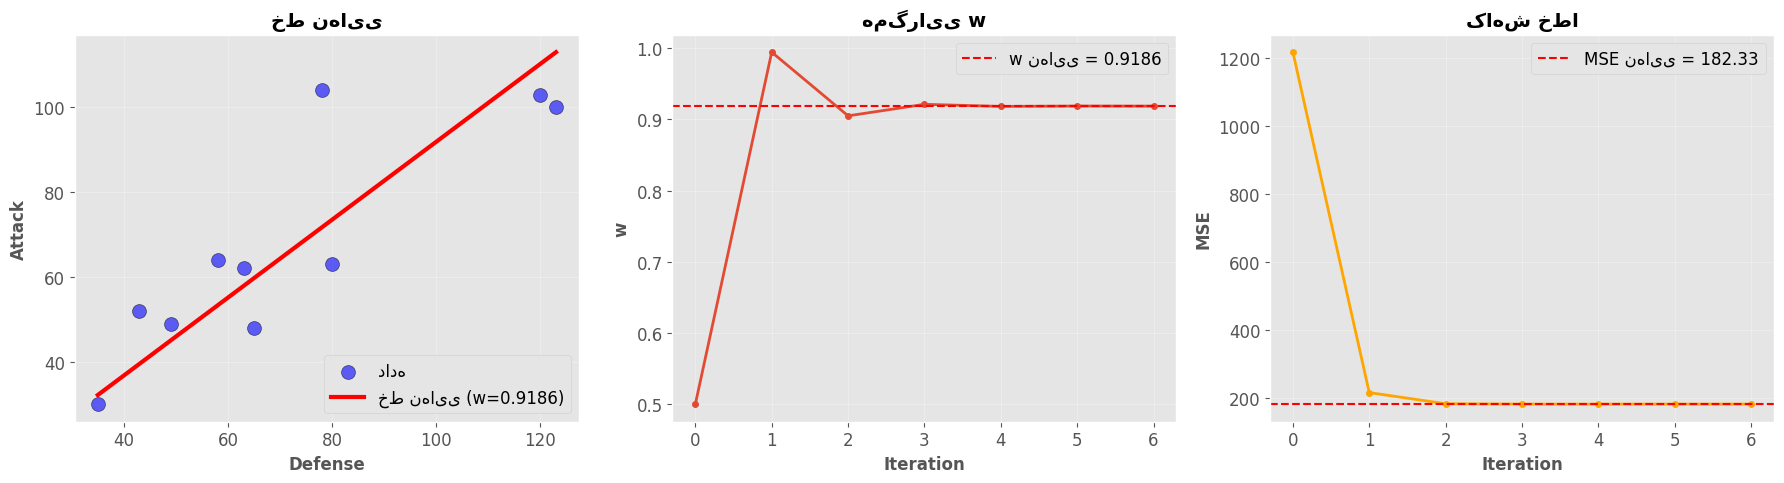

In [17]:
# رسم نمودار همگرایی
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# نمودار 1: خط نهایی
y_final = w_final * x
axes[0].scatter(x, y, color='blue', s=100, alpha=0.6, edgecolors='black', label='داده')
axes[0].plot(x, y_final, color='red', linewidth=3, label=f'خط نهایی (w={w_final:.4f})')
axes[0].set_xlabel('Defense', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Attack', fontsize=12, fontweight='bold')
axes[0].set_title('خط نهایی', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# نمودار 2: تغییرات w
axes[1].plot(history['w'], marker='o', linewidth=2, markersize=4)
axes[1].axhline(y=w_final, color='red', linestyle='--', label=f'w نهایی = {w_final:.4f}')
axes[1].set_xlabel('Iteration', fontsize=12, fontweight='bold')
axes[1].set_ylabel('w', fontsize=12, fontweight='bold')
axes[1].set_title('همگرایی w', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# نمودار 3: تغییرات MSE
axes[2].plot(history['mse'], marker='o', linewidth=2, markersize=4, color='orange')
axes[2].axhline(y=history['mse'][-1], color='red', linestyle='--',
                label=f'MSE نهایی = {history["mse"][-1]:.2f}')
axes[2].set_xlabel('Iteration', fontsize=12, fontweight='bold')
axes[2].set_ylabel('MSE', fontsize=12, fontweight='bold')
axes[2].set_title('کاهش خطا', fontsize=14, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4.2. Effect of Learning Rate
 اثر نرخ یادگیری (α) را بررسی می‌کنیم!

In [ ]:
# تست با نرخ‌های یادگیری مختلف
alphas = [0.5, 0.1, 0.0001]
results = {}

for alpha in alphas:
    print(f"\n{'='*50}")
    print(f"Testing α = {alpha}")
    print('='*50)

    w_final, history = gradient_descent(x, y, w_init=0.5, alpha=alpha,
                                       print_progress=100, max_iterations=5000)
    results[alpha] = history

    print(f"\n✅ با α={alpha}: w={w_final:.4f}, MSE={history['mse'][-1]:.2f}, iterations={len(history['w'])-1}")


Testing α = 0.5
Iteration 100: w=nan, MSE=nan, gradient=0.0000
Iteration 200: w=nan, MSE=nan, gradient=0.0000
Iteration 300: w=nan, MSE=nan, gradient=0.0000
Iteration 400: w=nan, MSE=nan, gradient=0.0000


/tmp/ipython-input-1621539130.py:27: RuntimeWarning: invalid value encountered in scalar subtract
  w_new = w - alpha * grad


Iteration 500: w=nan, MSE=nan, gradient=0.0000
Iteration 600: w=nan, MSE=nan, gradient=0.0000
Iteration 700: w=nan, MSE=nan, gradient=0.0000
Iteration 800: w=nan, MSE=nan, gradient=0.0000
Iteration 900: w=nan, MSE=nan, gradient=0.0000
Iteration 1000: w=nan, MSE=nan, gradient=0.0000
Iteration 1100: w=nan, MSE=nan, gradient=0.0000
Iteration 1200: w=nan, MSE=nan, gradient=0.0000
Iteration 1300: w=nan, MSE=nan, gradient=0.0000
Iteration 1400: w=nan, MSE=nan, gradient=0.0000
Iteration 1500: w=nan, MSE=nan, gradient=0.0000
Iteration 1600: w=nan, MSE=nan, gradient=0.0000
Iteration 1700: w=nan, MSE=nan, gradient=0.0000
Iteration 1800: w=nan, MSE=nan, gradient=0.0000
Iteration 1900: w=nan, MSE=nan, gradient=0.0000
Iteration 2000: w=nan, MSE=nan, gradient=0.0000
Iteration 2100: w=nan, MSE=nan, gradient=0.0000
Iteration 2200: w=nan, MSE=nan, gradient=0.0000
Iteration 2300: w=nan, MSE=nan, gradient=0.0000
Iteration 2400: w=nan, MSE=nan, gradient=0.0000
Iteration 2500: w=nan, MSE=nan, gradient=0.00

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


Iteration 1000: w=nan, MSE=nan, gradient=0.0000
Iteration 1100: w=nan, MSE=nan, gradient=0.0000
Iteration 1200: w=nan, MSE=nan, gradient=0.0000
Iteration 1300: w=nan, MSE=nan, gradient=0.0000
Iteration 1400: w=nan, MSE=nan, gradient=0.0000
Iteration 1500: w=nan, MSE=nan, gradient=0.0000
Iteration 1600: w=nan, MSE=nan, gradient=0.0000
Iteration 1700: w=nan, MSE=nan, gradient=0.0000
Iteration 1800: w=nan, MSE=nan, gradient=0.0000
Iteration 1900: w=nan, MSE=nan, gradient=0.0000
Iteration 2000: w=nan, MSE=nan, gradient=0.0000
Iteration 2100: w=nan, MSE=nan, gradient=0.0000
Iteration 2200: w=nan, MSE=nan, gradient=0.0000
Iteration 2300: w=nan, MSE=nan, gradient=0.0000
Iteration 2400: w=nan, MSE=nan, gradient=0.0000
Iteration 2500: w=nan, MSE=nan, gradient=0.0000
Iteration 2600: w=nan, MSE=nan, gradient=0.0000
Iteration 2700: w=nan, MSE=nan, gradient=0.0000
Iteration 2800: w=nan, MSE=nan, gradient=0.0000
Iteration 2900: w=nan, MSE=nan, gradient=0.0000
Iteration 3000: w=nan, MSE=nan, gradient

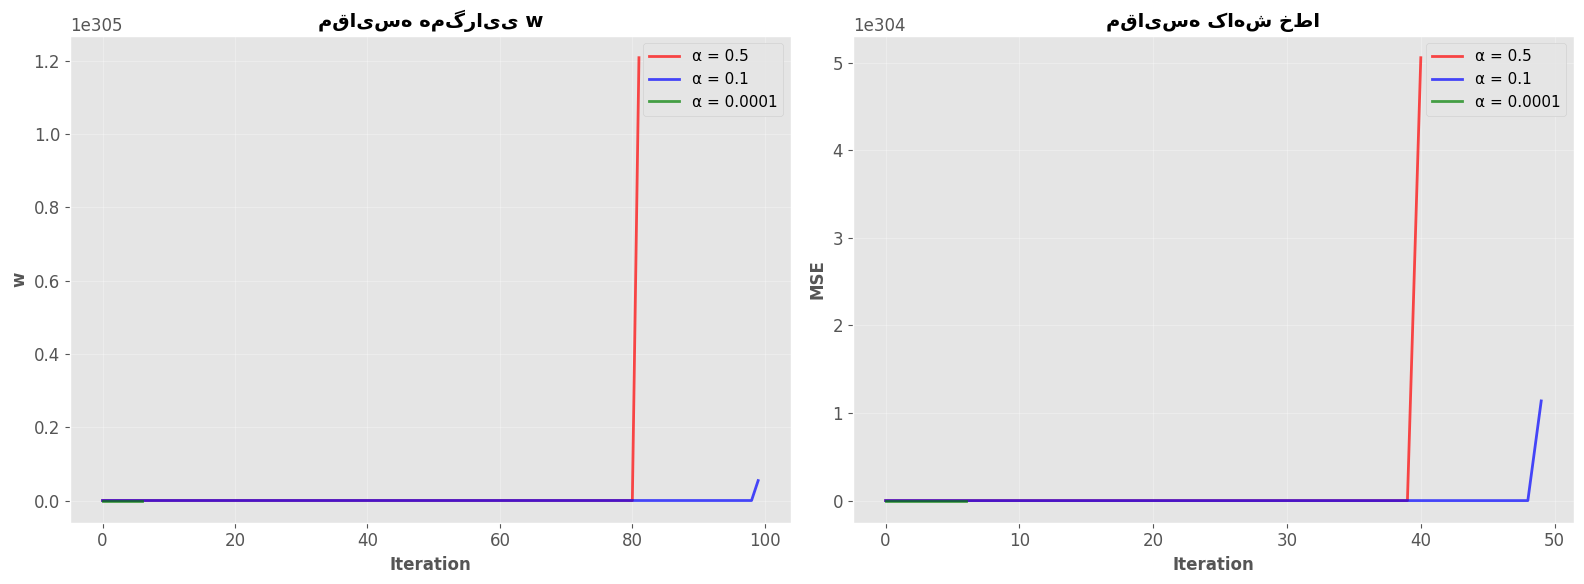


📊 مشاهدات:
   α=0.5  → همگرایی سریع ولی ممکن است واگرا شود!
   α=0.1  → همگرایی خوب و پایدار
   α=0.0001 → همگرایی خیلی کند


In [ ]:
# مقایسه نرخ‌های یادگیری
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['red', 'blue', 'green']

# نمودار 1: تغییرات w
for i, alpha in enumerate(alphas):
    axes[0].plot(results[alpha]['w'], label=f'α = {alpha}',
                color=colors[i], linewidth=2, alpha=0.7)
axes[0].set_xlabel('Iteration', fontsize=12, fontweight='bold')
axes[0].set_ylabel('w', fontsize=12, fontweight='bold')
axes[0].set_title('مقایسه همگرایی w', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# نمودار 2: تغییرات MSE
for i, alpha in enumerate(alphas):
    axes[1].plot(results[alpha]['mse'], label=f'α = {alpha}',
                color=colors[i], linewidth=2, alpha=0.7)
axes[1].set_xlabel('Iteration', fontsize=12, fontweight='bold')
axes[1].set_ylabel('MSE', fontsize=12, fontweight='bold')
axes[1].set_title('مقایسه کاهش خطا', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 مشاهدات:")
print("   α=0.5  → همگرایی سریع ولی ممکن است واگرا شود!")
print("   α=0.1  → همگرایی خوب و پایدار")
print("   α=0.0001 → همگرایی خیلی کند")

## 4.3. Gradient Descent with Two Parameters (25 points)

حالا هم شیب (w1) و هم عرض از مبدا (w0) را پیدا می‌کنیم!

In [18]:
# تابع گرادیان برای دو پارامتر
def gradient_2d(x, y, w):
    """
    محاسبه گرادیان برای w = [w0, w1]

    گرادیان w0: (2/n) * sum((w0 + w1*x - y))
    گرادیان w1: (2/n) * sum(x * (w0 + w1*x - y))
    """
    w0, w1 = w[0], w[1]
    n = len(x)

    y_pred = w0 + w1 * x
    error = y_pred - y

    grad_w0 = (2/n) * np.sum(error)
    grad_w1 = (2/n) * np.sum(x * error)

    return np.array([grad_w0, grad_w1])

# تست
test_grad = gradient_2d(x, y, w=[0, 0.5])
print(f"✅ گرادیان در w=[0, 0.5]: [{test_grad[0]:.2f}, {test_grad[1]:.2f}]")

✅ گرادیان در w=[0, 0.5]: [-63.60, -4942.80]


In [19]:
# تابع MSE برای دو پارامتر
def mse_2d(x, y, w):
    """محاسبه MSE برای w = [w0, w1]"""
    w0, w1 = w[0], w[1]
    y_pred = w0 + w1 * x
    return np.mean((y - y_pred)**2)

print("✅ تابع MSE برای 2 پارامتر آماده شد!")

✅ تابع MSE برای 2 پارامتر آماده شد!


In [20]:
# Gradient Descent برای دو پارامتر
def gradient_descent_2d(x, y, w_init, alpha, epsilon=2e-4, max_iterations=5000, print_progress=50):
    """
    الگوریتم گرادیان کاهشی برای دو پارامتر
    """
    w = np.array(w_init)
    history = {
        'w0': [w[0]],
        'w1': [w[1]],
        'mse': [mse_2d(x, y, w)]
    }

    for i in range(max_iterations):
        # محاسبه گرادیان
        grad = gradient_2d(x, y, w)

        # به‌روزرسانی
        w_new = w - alpha * grad

        # ذخیره
        mse = mse_2d(x, y, w_new)
        history['w0'].append(w_new[0])
        history['w1'].append(w_new[1])
        history['mse'].append(mse)

        # نمایش
        if (i+1) % print_progress == 0:
            print(f"Iteration {i+1}: w0={w_new[0]:.4f}, w1={w_new[1]:.4f}, MSE={mse:.2f}")

        # شرط توقف
        if np.linalg.norm(w_new - w) < epsilon:
            print(f"\n✅ همگرا شد در iteration {i+1}!")
            break

        w = w_new

    return w, history

print("✅ تابع Gradient Descent 2D آماده شد!")

✅ تابع Gradient Descent 2D آماده شد!


In [21]:
# اجرای Gradient Descent 2D
print("🚀 شروع Gradient Descent با 2 پارامتر...\n")

w_init = [0, 0.5]  # [w0, w1]
alpha = 0.0001

w_final, history_2d = gradient_descent_2d(x, y, w_init, alpha)

print(f"\n🎯 نتیجه نهایی:")
print(f"   w0 = {w_final[0]:.4f}")
print(f"   w1 = {w_final[1]:.4f}")
print(f"   MSE = {history_2d['mse'][-1]:.2f}")
print(f"   معادله خط: y = {w_final[0]:.4f} + {w_final[1]:.4f}*x")

🚀 شروع Gradient Descent با 2 پارامتر...

Iteration 50: w0=0.0242, w1=0.9183, MSE=182.24
Iteration 100: w0=0.0433, w1=0.9180, MSE=182.17
Iteration 150: w0=0.0624, w1=0.9178, MSE=182.09
Iteration 200: w0=0.0814, w1=0.9176, MSE=182.02
Iteration 250: w0=0.1004, w1=0.9173, MSE=181.95
Iteration 300: w0=0.1194, w1=0.9171, MSE=181.88
Iteration 350: w0=0.1384, w1=0.9169, MSE=181.81
Iteration 400: w0=0.1574, w1=0.9167, MSE=181.73
Iteration 450: w0=0.1763, w1=0.9164, MSE=181.66
Iteration 500: w0=0.1952, w1=0.9162, MSE=181.59
Iteration 550: w0=0.2141, w1=0.9160, MSE=181.52
Iteration 600: w0=0.2329, w1=0.9157, MSE=181.45
Iteration 650: w0=0.2517, w1=0.9155, MSE=181.38
Iteration 700: w0=0.2705, w1=0.9153, MSE=181.31
Iteration 750: w0=0.2893, w1=0.9151, MSE=181.24
Iteration 800: w0=0.3080, w1=0.9148, MSE=181.17
Iteration 850: w0=0.3267, w1=0.9146, MSE=181.10
Iteration 900: w0=0.3454, w1=0.9144, MSE=181.03
Iteration 950: w0=0.3641, w1=0.9142, MSE=180.96
Iteration 1000: w0=0.3827, w1=0.9139, MSE=180.89

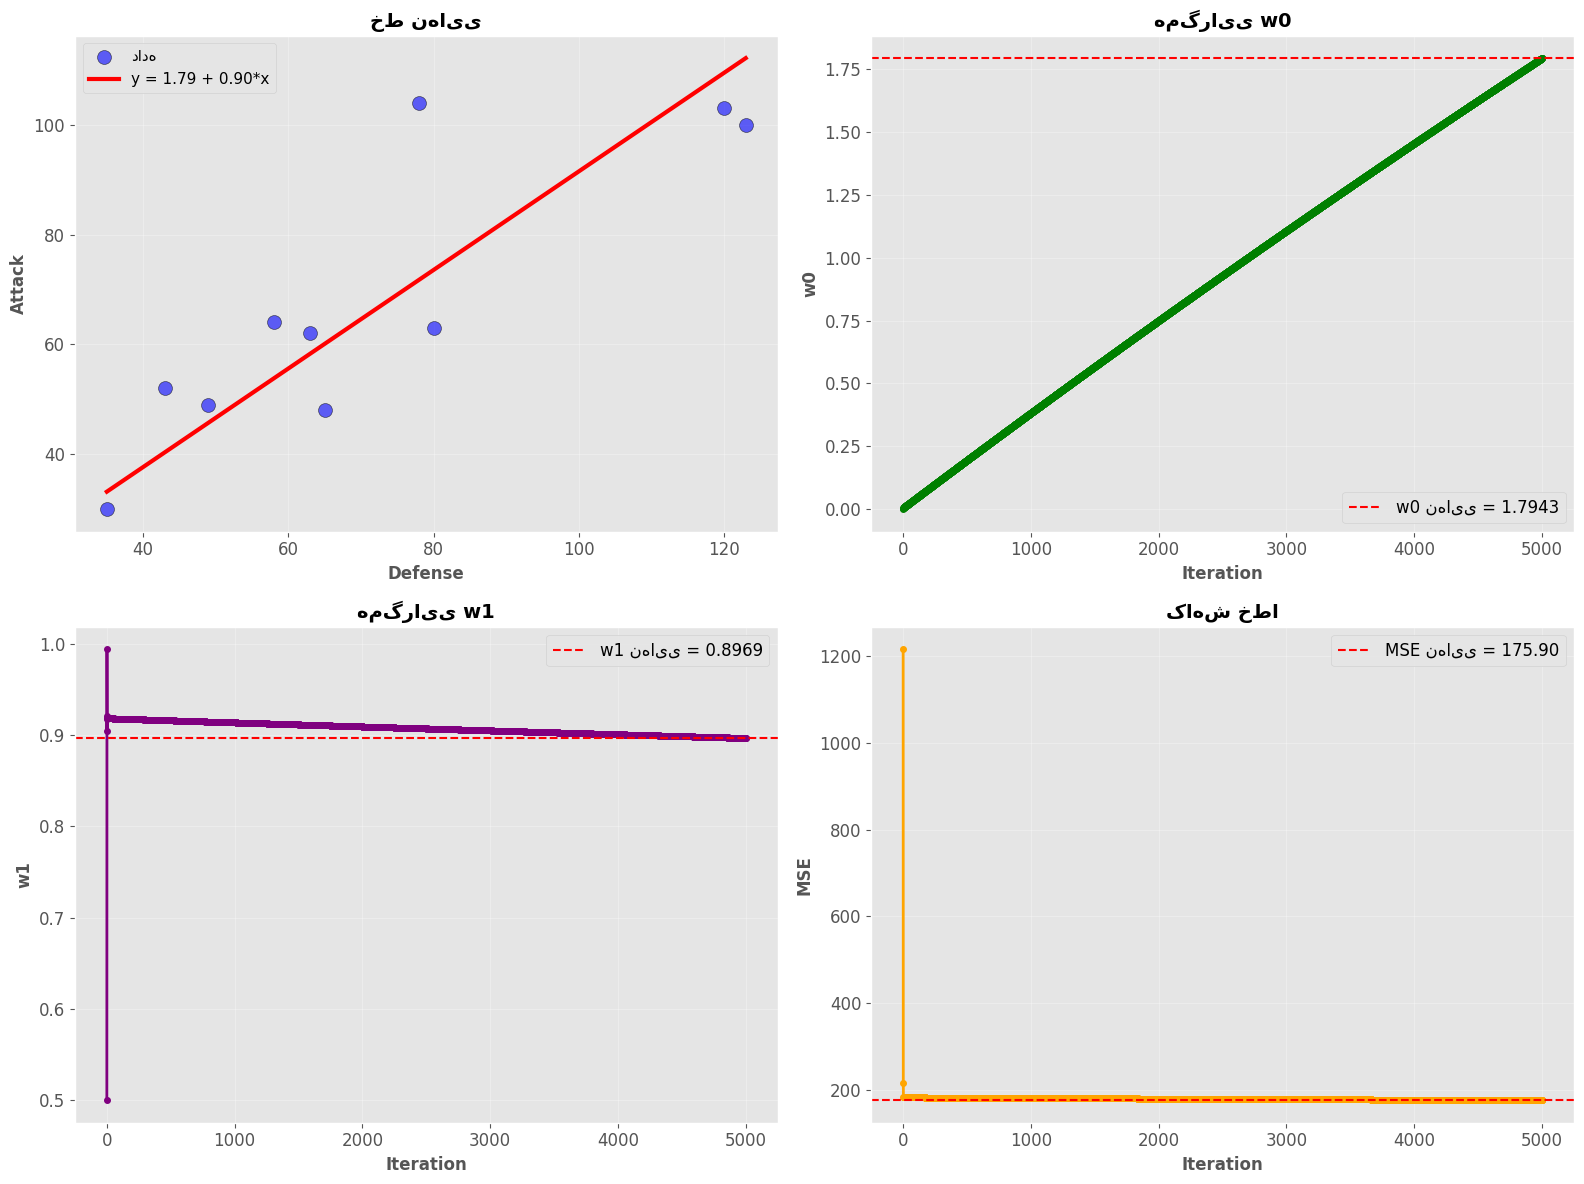

In [22]:
# رسم نمودار نتایج
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# نمودار 1: خط نهایی
y_final = w_final[0] + w_final[1] * x
axes[0, 0].scatter(x, y, color='blue', s=100, alpha=0.6, edgecolors='black', label='داده')
axes[0, 0].plot(x, y_final, color='red', linewidth=3,
                label=f'y = {w_final[0]:.2f} + {w_final[1]:.2f}*x')
axes[0, 0].set_xlabel('Defense', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Attack', fontsize=12, fontweight='bold')
axes[0, 0].set_title('خط نهایی', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# نمودار 2: همگرایی w0
axes[0, 1].plot(history_2d['w0'], marker='o', linewidth=2, markersize=4, color='green')
axes[0, 1].axhline(y=w_final[0], color='red', linestyle='--',
                   label=f'w0 نهایی = {w_final[0]:.4f}')
axes[0, 1].set_xlabel('Iteration', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('w0', fontsize=12, fontweight='bold')
axes[0, 1].set_title('همگرایی w0', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# نمودار 3: همگرایی w1
axes[1, 0].plot(history_2d['w1'], marker='o', linewidth=2, markersize=4, color='purple')
axes[1, 0].axhline(y=w_final[1], color='red', linestyle='--',
                   label=f'w1 نهایی = {w_final[1]:.4f}')
axes[1, 0].set_xlabel('Iteration', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('w1', fontsize=12, fontweight='bold')
axes[1, 0].set_title('همگرایی w1', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# نمودار 4: کاهش MSE
axes[1, 1].plot(history_2d['mse'], marker='o', linewidth=2, markersize=4, color='orange')
axes[1, 1].axhline(y=history_2d['mse'][-1], color='red', linestyle='--',
                   label=f'MSE نهایی = {history_2d["mse"][-1]:.2f}')
axes[1, 1].set_xlabel('Iteration', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('MSE', fontsize=12, fontweight='bold')
axes[1, 1].set_title('کاهش خطا', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

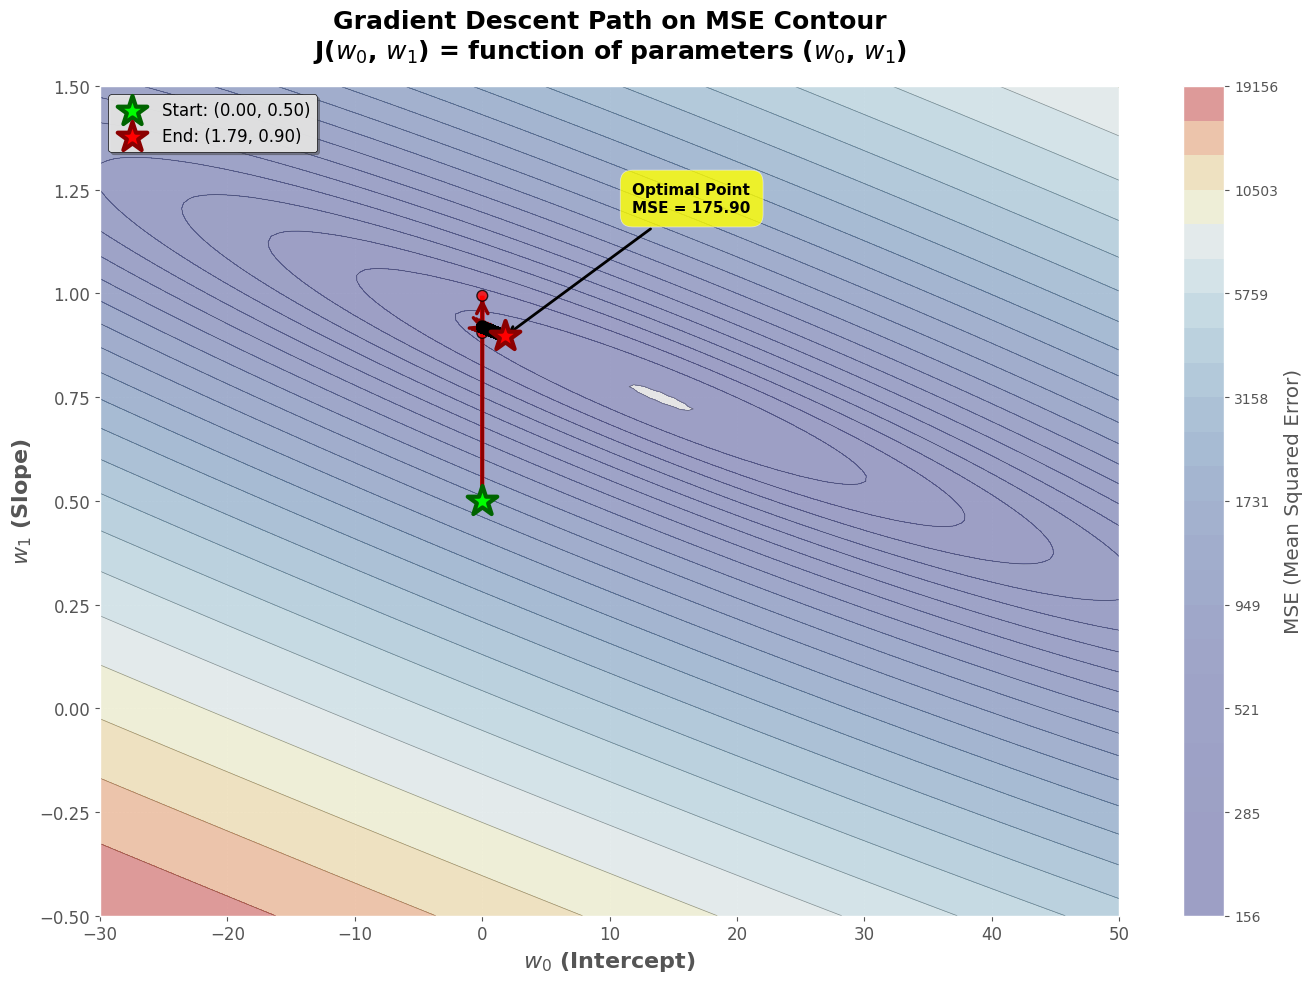

✅ نمودار Contour حرفه‌ای رسم شد!

📊 تحلیل مسیر:
   • نقطه شروع: w0=0.00, w1=0.50
   • نقطه پایان: w0=1.79, w1=0.90
   • تغییر w0: 1.79
   • تغییر w1: 0.40
   • تعداد گام: 5000
   • MSE نهایی: 175.90


In [23]:
#  نمودار Contour
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# ساخت شبکه دقیق‌تر
w0_range = np.linspace(-30, 50, 150)
w1_range = np.linspace(-0.5, 1.5, 150)
W0, W1 = np.meshgrid(w0_range, w1_range)

# محاسبه MSE
MSE = np.zeros_like(W0)
for i in range(W0.shape[0]):
    for j in range(W0.shape[1]):
        y_pred = W0[i, j] + W1[i, j] * x
        MSE[i, j] = np.mean((y - y_pred)**2)

# رسم
fig, ax = plt.subplots(figsize=(14, 10))

# Contour ا رنگ‌بندی ا
levels = np.logspace(np.log10(MSE.min()+1), np.log10(MSE.max()), 25)
contourf = ax.contourf(W0, W1, MSE, levels=levels, cmap='RdYlBu_r', alpha=0.4)
contour = ax.contour(W0, W1, MSE, levels=levels, colors='black',
                     linewidths=0.5, alpha=0.4)

# Colorbar
cbar = plt.colorbar(contourf, ax=ax, label='MSE (Mean Squared Error)')
cbar.ax.tick_params(labelsize=10)

# مسیر گرادیان کاهشی
path_w0 = history_2d['w0']
path_w1 = history_2d['w1']

# رسم مسیر با گرادیان رنگی
points = np.array([path_w0, path_w1]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

from matplotlib.collections import LineCollection
lc = LineCollection(segments, cmap='autumn', linewidths=3)
lc.set_array(np.arange(len(path_w0)))
line = ax.add_collection(lc)

# نقاط روی مسیر
scatter = ax.scatter(path_w0, path_w1, c=range(len(path_w0)),
                    cmap='autumn', s=60, edgecolors='black',
                    linewidth=1, zorder=5, alpha=0.8)

# نقطه شروع
ax.scatter(path_w0[0], path_w1[0], c='lime', s=500, marker='*',
          edgecolors='darkgreen', linewidth=3, zorder=10,
          label=f'Start: ({path_w0[0]:.2f}, {path_w1[0]:.2f})')

# نقطه پایان
ax.scatter(path_w0[-1], path_w1[-1], c='red', s=500, marker='*',
          edgecolors='darkred', linewidth=3, zorder=10,
          label=f'End: ({path_w0[-1]:.2f}, {path_w1[-1]:.2f})')

# فلش‌های جهت
step = max(1, len(path_w0)//8)
for i in range(0, len(path_w0)-1, step):
    ax.annotate('', xy=(path_w0[i+1], path_w1[i+1]),
                xytext=(path_w0[i], path_w1[i]),
                arrowprops=dict(arrowstyle='->', color='darkred',
                              lw=2.5, mutation_scale=20))

# عنوان و برچسب‌ها
ax.set_xlabel('$w_0$ (Intercept)', fontsize=16, fontweight='bold')
ax.set_ylabel('$w_1$ (Slope)', fontsize=16, fontweight='bold')
ax.set_title('Gradient Descent Path on MSE Contour\n' +
            f'J($w_0$, $w_1$) = function of parameters ($w_0$, $w_1$)',
            fontsize=18, fontweight='bold', pad=20)

# راهنما
ax.legend(fontsize=12, loc='upper left', framealpha=0.95,
         edgecolor='black', fancybox=True, shadow=True)

# شبکه
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)

# محدوده محورها
ax.set_xlim([w0_range.min(), w0_range.max()])
ax.set_ylim([w1_range.min(), w1_range.max()])

# آنوتیشن برای نقطه بهینه
ax.annotate(f'Optimal Point\nMSE = {history_2d["mse"][-1]:.2f}',
           xy=(path_w0[-1], path_w1[-1]),
           xytext=(path_w0[-1]+10, path_w1[-1]+0.3),
           fontsize=11, fontweight='bold',
           bbox=dict(boxstyle='round,pad=0.8', facecolor='yellow', alpha=0.8),
           arrowprops=dict(arrowstyle='->', lw=2, color='black'))

plt.tight_layout()
plt.show()

print("✅ نمودار Contour حرفه‌ای رسم شد!")
print(f"\n📊 تحلیل مسیر:")
print(f"   • نقطه شروع: w0={path_w0[0]:.2f}, w1={path_w1[0]:.2f}")
print(f"   • نقطه پایان: w0={path_w0[-1]:.2f}, w1={path_w1[-1]:.2f}")
print(f"   • تغییر w0: {path_w0[-1]-path_w0[0]:.2f}")
print(f"   • تغییر w1: {path_w1[-1]-path_w1[0]:.2f}")
print(f"   • تعداد گام: {len(path_w0)-1}")
print(f"   • MSE نهایی: {history_2d['mse'][-1]:.2f}")

## 4.4. Effect of Normalization

In [25]:
# نرمال‌سازی داده x
x_mean = x.mean()
x_std = x.std()

x_normalized = (x - x_mean) / x_std

print("آمار داده قبل از نرمال‌سازی:")
print(f"   میانگین x: {x_mean:.2f}")
print(f"   انحراف معیار x: {x_std:.2f}")
print(f"\n آمار داده بعد از نرمال‌سازی:")
print(f"   میانگین x_normalized: {x_normalized.mean():.6f}")
print(f"   انحراف معیار x_normalized: {x_normalized.std():.6f}")

آمار داده قبل از نرمال‌سازی:
   میانگین x: 71.40
   انحراف معیار x: 29.94

 آمار داده بعد از نرمال‌سازی:
   میانگین x_normalized: -0.000000
   انحراف معیار x_normalized: 1.000000


In [26]:
# مقایسه گرادیان‌ها قبل و بعد از نرمال‌سازی


w_test = [10, 0.5]

grad_before = gradient_2d(x, y, w_test)
grad_after = gradient_2d(x_normalized, y, w_test)

print(f"گرادیان قبل از نرمال‌سازی: [{grad_before[0]:.2f}, {grad_before[1]:.2f}]")
print(f"گرادیان بعد از نرمال‌سازی: [{grad_after[0]:.2f}, {grad_after[1]:.2f}]")
print(f"\n💡 گرادیان‌ها در یک مقیاس مشابه شدند!")

گرادیان قبل از نرمال‌سازی: [-43.60, -3514.80]
گرادیان بعد از نرمال‌سازی: [-115.00, -39.46]

💡 گرادیان‌ها در یک مقیاس مشابه شدند!


In [28]:
# اجرای Gradient Descent با داده بدون نرمال‌سازی
print("اجرای Gradient Descent با 2 پارامتر (بدون نرمال‌سازی)...\n")

w_init = [0, 0.5]
alpha = 0.0001
print(f" تنظیمات:")
print(f"   w اولیه: {w_init}")
print(f"   Learning rate (α): {alpha}")
print(f"   حداکثر iterations: 5000\n")

w_final, history_2d = gradient_descent_2d(x, y, w_init, alpha, print_progress=100)

print(f"\n نتیجه نهایی:")
print(f"   w0 = {w_final[0]:.4f}")
print(f"   w1 = {w_final[1]:.4f}")
print(f"   MSE = {history_2d['mse'][-1]:.2f}")
print(f"   تعداد iteration: {len(history_2d['mse'])-1}")
print(f"   معادله خط: y = {w_final[0]:.4f} + {w_final[1]:.4f}*x")

اجرای Gradient Descent با 2 پارامتر (بدون نرمال‌سازی)...

 تنظیمات:
   w اولیه: [0, 0.5]
   Learning rate (α): 0.0001
   حداکثر iterations: 5000

Iteration 100: w0=0.0433, w1=0.9180, MSE=182.17
Iteration 200: w0=0.0814, w1=0.9176, MSE=182.02
Iteration 300: w0=0.1194, w1=0.9171, MSE=181.88
Iteration 400: w0=0.1574, w1=0.9167, MSE=181.73
Iteration 500: w0=0.1952, w1=0.9162, MSE=181.59
Iteration 600: w0=0.2329, w1=0.9157, MSE=181.45
Iteration 700: w0=0.2705, w1=0.9153, MSE=181.31
Iteration 800: w0=0.3080, w1=0.9148, MSE=181.17
Iteration 900: w0=0.3454, w1=0.9144, MSE=181.03
Iteration 1000: w0=0.3827, w1=0.9139, MSE=180.89
Iteration 1100: w0=0.4199, w1=0.9135, MSE=180.75
Iteration 1200: w0=0.4570, w1=0.9130, MSE=180.61
Iteration 1300: w0=0.4940, w1=0.9126, MSE=180.47
Iteration 1400: w0=0.5309, w1=0.9121, MSE=180.34
Iteration 1500: w0=0.5677, w1=0.9117, MSE=180.20
Iteration 1600: w0=0.6044, w1=0.9112, MSE=180.07
Iteration 1700: w0=0.6410, w1=0.9108, MSE=179.93
Iteration 1800: w0=0.6775, w1=

In [30]:
# اجرای Gradient Descent با داده نرمال شده
print(" اجرای Gradient Descent با داده نرمال شده...")

w_init = [0, 0.5]
alpha = 0.1  #  با داده نرمال، می‌تونیم alpha بزرگتر استفاده کنیم!

print(f" تنظیمات:")
print(f"   w اولیه: {w_init}")
print(f"   Learning rate (α): {alpha}")


w_final_norm, history_norm = gradient_descent_2d(x_normalized, y, w_init, alpha, print_progress=50)

print(f"\n نتیجه با داده نرمال:")
print(f"   w0 = {w_final_norm[0]:.4f}")
print(f"   w1 = {w_final_norm[1]:.4f}")
print(f"   MSE = {history_norm['mse'][-1]:.2f}")
print(f"   تعداد iteration: {len(history_norm['mse'])-1}")

 اجرای Gradient Descent با داده نرمال شده...
 تنظیمات:
   w اولیه: [0, 0.5]
   Learning rate (α): 0.1
Iteration 50: w0=67.4990, w1=22.4233, MSE=155.48

✅ همگرا شد در iteration 53!

 نتیجه با داده نرمال:
   w0 = 67.4994
   w1 = 22.4236
   MSE = 155.48
   تعداد iteration: 53


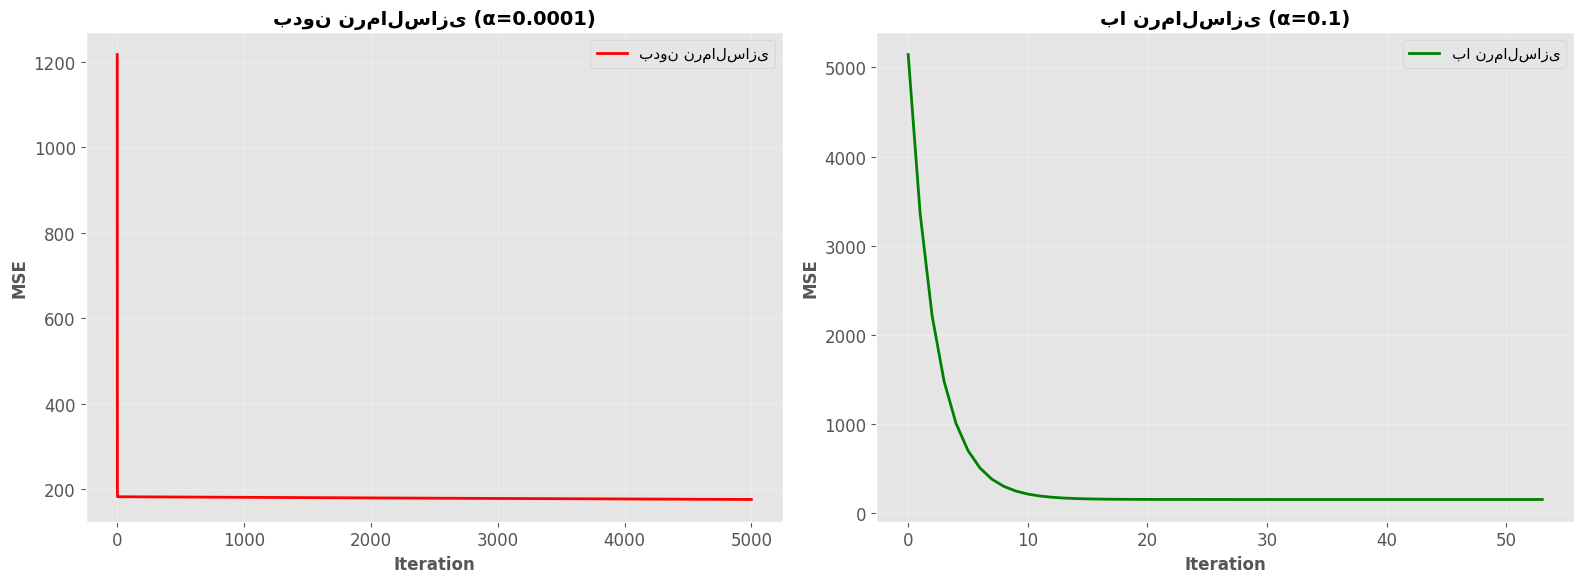


 نتیجه مقایسه:
   🔴 بدون نرمال‌سازی (α=0.0001): 5000 iteration
   🟢 با نرمال‌سازی (α=0.1): 53 iteration
   
    با نرمال‌سازی:
      ✅ می‌توانیم alpha بزرگتر استفاده کنیم (0.0001 → 0.1)
      ✅ سرعت همگرایی 94.3× بهبود یافت!


In [31]:
# مقایسه قبل و بعد از نرمال‌سازی
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# نمودار 1: بدون نرمال‌سازی
axes[0].plot(history_2d['mse'], linewidth=2, label='بدون نرمال‌سازی', color='red')
axes[0].set_xlabel('Iteration', fontsize=12, fontweight='bold')
axes[0].set_ylabel('MSE', fontsize=12, fontweight='bold')
axes[0].set_title('بدون نرمال‌سازی (α=0.0001)', fontsize=14, fontweight='bold')  # ⭐ اصلاح شد
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# نمودار 2: با نرمال‌سازی
axes[1].plot(history_norm['mse'], linewidth=2, label='با نرمال‌سازی', color='green')
axes[1].set_xlabel('Iteration', fontsize=12, fontweight='bold')
axes[1].set_ylabel('MSE', fontsize=12, fontweight='bold')
axes[1].set_title('با نرمال‌سازی (α=0.1)', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n نتیجه مقایسه:")
print(f"   🔴 بدون نرمال‌سازی (α=0.0001): {len(history_2d['mse'])-1} iteration")
print(f"   🟢 با نرمال‌سازی (α=0.1): {len(history_norm['mse'])-1} iteration")
print(f"   ")
print(f"    با نرمال‌سازی:")
print(f"      ✅ می‌توانیم alpha بزرگتر استفاده کنیم (0.0001 → 0.1)")
print(f"      ✅ سرعت همگرایی {(len(history_2d['mse'])-1)/(len(history_norm['mse'])-1):.1f}× بهبود یافت!")

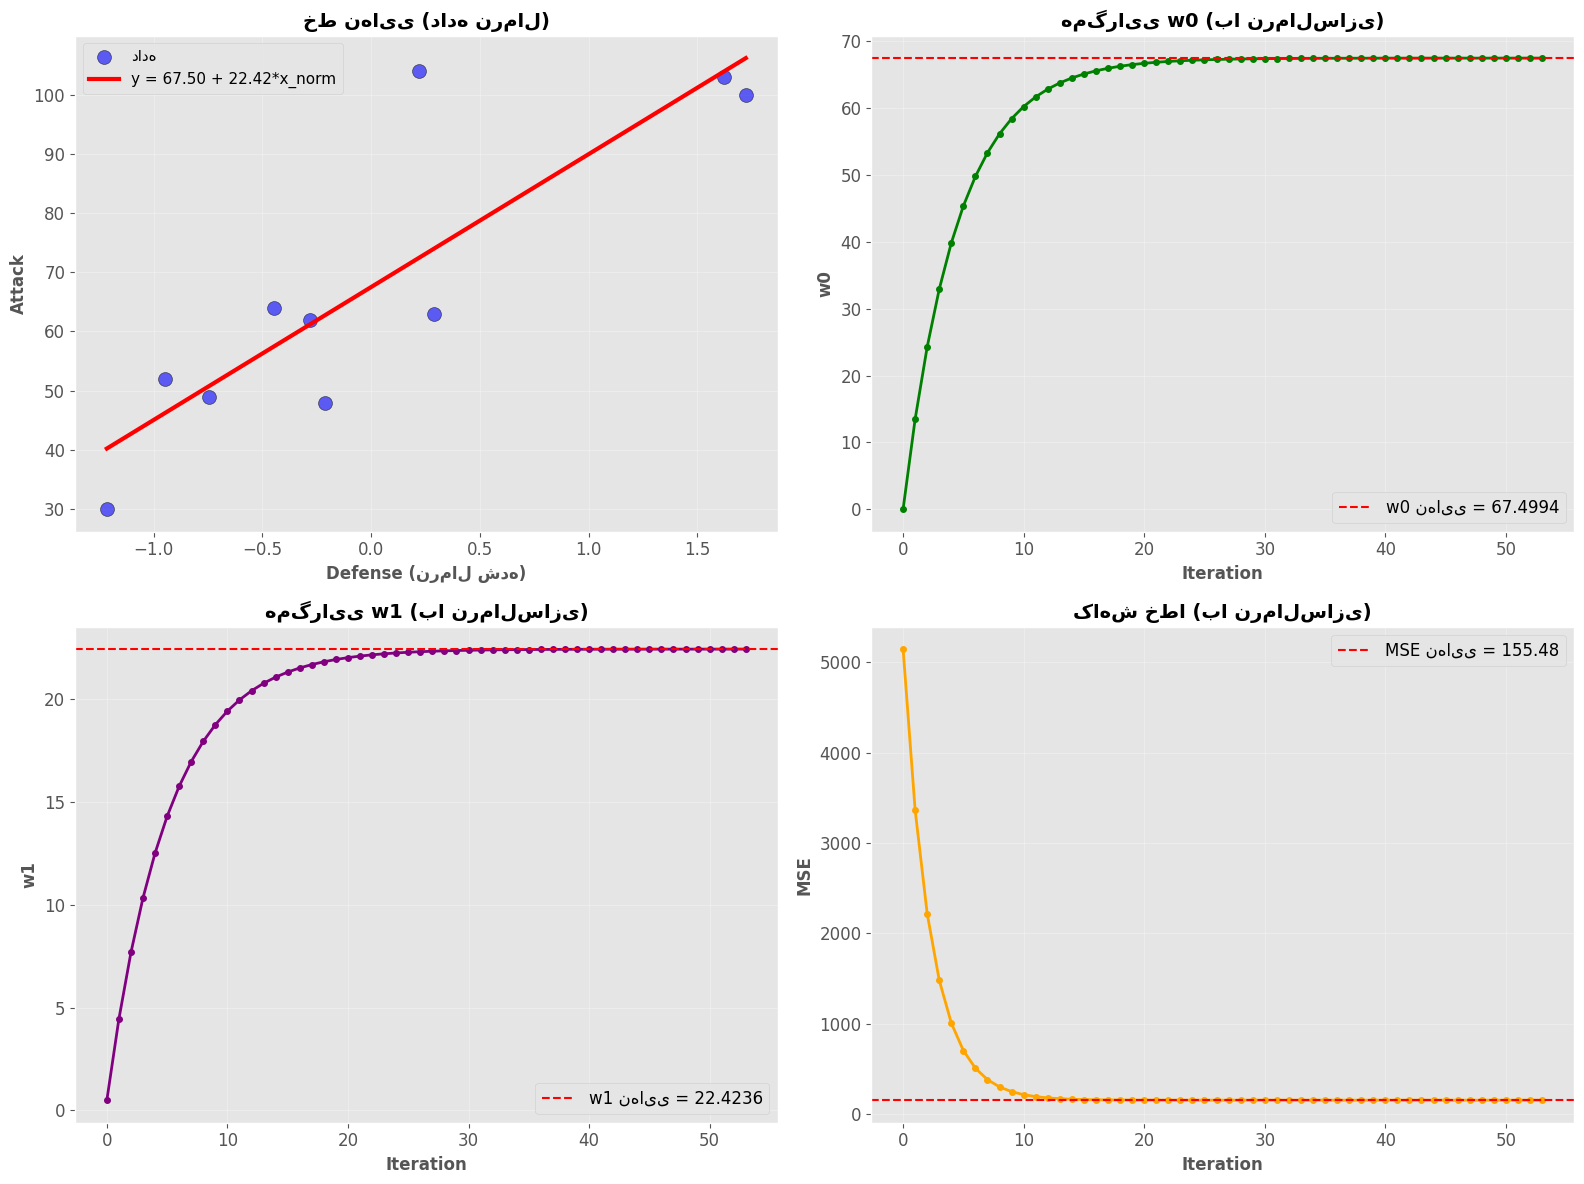

✅ نمودارهای 4تایی برای داده نرمال رسم شد!


In [32]:
# نمودارهای کامل برای داده نرمال شده
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# نمودار 1: خط نهایی روی داده نرمال
y_final_norm = w_final_norm[0] + w_final_norm[1] * x_normalized
axes[0, 0].scatter(x_normalized, y, color='blue', s=100, alpha=0.6,
                   edgecolors='black', label='داده')
axes[0, 0].plot(x_normalized, y_final_norm, color='red', linewidth=3,
                label=f'y = {w_final_norm[0]:.2f} + {w_final_norm[1]:.2f}*x_norm')
axes[0, 0].set_xlabel('Defense (نرمال شده)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Attack', fontsize=12, fontweight='bold')
axes[0, 0].set_title('خط نهایی (داده نرمال)', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# نمودار 2: همگرایی w0
axes[0, 1].plot(history_norm['w0'], marker='o', linewidth=2, markersize=4, color='green')
axes[0, 1].axhline(y=w_final_norm[0], color='red', linestyle='--',
                   label=f'w0 نهایی = {w_final_norm[0]:.4f}')
axes[0, 1].set_xlabel('Iteration', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('w0', fontsize=12, fontweight='bold')
axes[0, 1].set_title('همگرایی w0 (با نرمال‌سازی)', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# نمودار 3: همگرایی w1
axes[1, 0].plot(history_norm['w1'], marker='o', linewidth=2, markersize=4, color='purple')
axes[1, 0].axhline(y=w_final_norm[1], color='red', linestyle='--',
                   label=f'w1 نهایی = {w_final_norm[1]:.4f}')
axes[1, 0].set_xlabel('Iteration', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('w1', fontsize=12, fontweight='bold')
axes[1, 0].set_title('همگرایی w1 (با نرمال‌سازی)', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# نمودار 4: کاهش MSE
axes[1, 1].plot(history_norm['mse'], marker='o', linewidth=2, markersize=4, color='orange')
axes[1, 1].axhline(y=history_norm['mse'][-1], color='red', linestyle='--',
                   label=f'MSE نهایی = {history_norm["mse"][-1]:.2f}')
axes[1, 1].set_xlabel('Iteration', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('MSE', fontsize=12, fontweight='bold')
axes[1, 1].set_title('کاهش خطا (با نرمال‌سازی)', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ نمودارهای 4تایی برای داده نرمال رسم شد!")

/tmp/ipython-input-4282070998.py:50: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


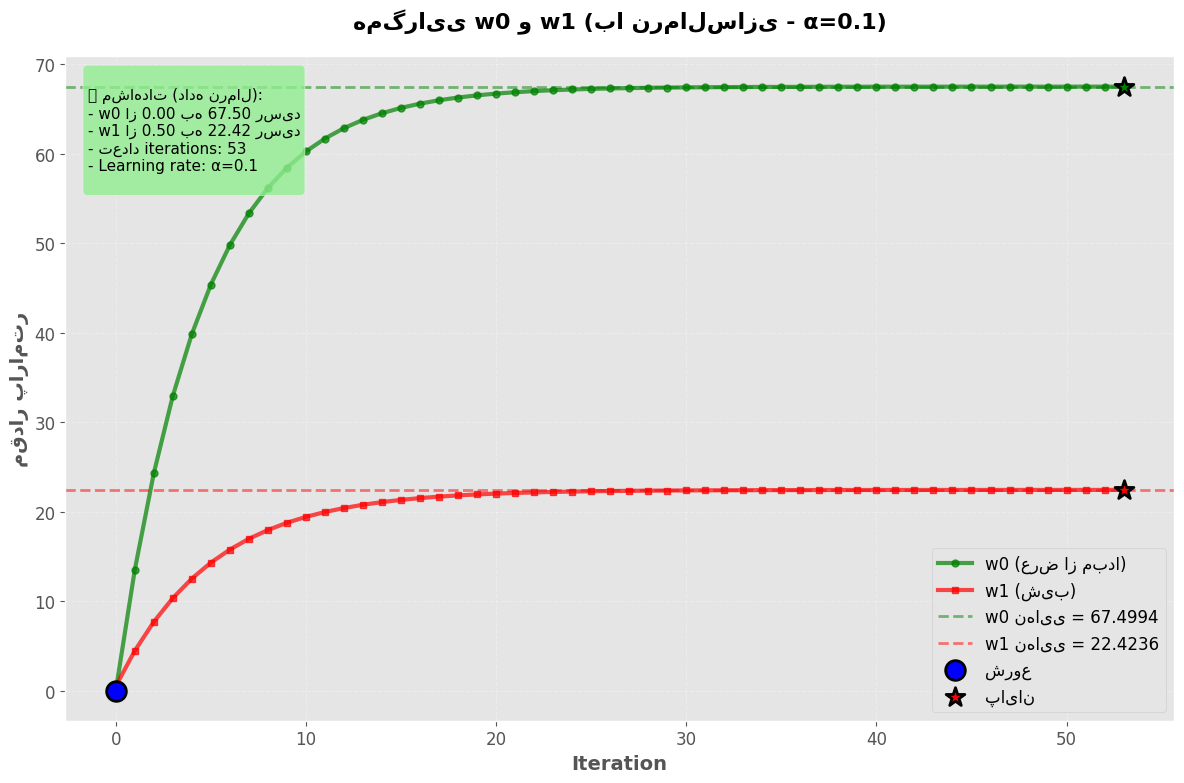

✅ نمودار ترکیبی w0 & w1 برای داده نرمال رسم شد!


In [33]:
#  نمودار ترکیبی w0 و w1 (داده نرمال)
fig, ax = plt.subplots(figsize=(12, 8))

iterations_norm = range(len(history_norm['w0']))

# رسم w0
ax.plot(iterations_norm, history_norm['w0'],
        color='green', linewidth=3, marker='o', markersize=5,
        label='w0 (عرض از مبدا)', alpha=0.7)

# رسم w1
ax.plot(iterations_norm, history_norm['w1'],
        color='red', linewidth=3, marker='s', markersize=5,
        label='w1 (شیب)', alpha=0.7)

# خطوط افقی
ax.axhline(y=w_final_norm[0], color='green', linestyle='--', linewidth=2,
           alpha=0.5, label=f'w0 نهایی = {w_final_norm[0]:.4f}')
ax.axhline(y=w_final_norm[1], color='red', linestyle='--', linewidth=2,
           alpha=0.5, label=f'w1 نهایی = {w_final_norm[1]:.4f}')

# نقاط شروع و پایان
ax.scatter([0], [history_norm['w0'][0]], color='blue', s=200,
          zorder=5, edgecolors='black', linewidth=2, label='شروع')
ax.scatter([len(history_norm['w0'])-1], [w_final_norm[0]], color='green',
          s=200, marker='*', zorder=5, edgecolors='black', linewidth=2)
ax.scatter([len(history_norm['w1'])-1], [w_final_norm[1]], color='red',
          s=200, marker='*', zorder=5, edgecolors='black', linewidth=2,
          label='پایان')

ax.set_xlabel('Iteration', fontsize=14, fontweight='bold')
ax.set_ylabel('مقدار پارامتر', fontsize=14, fontweight='bold')
ax.set_title('همگرایی w0 و w1 (با نرمال‌سازی - α=0.1)',
            fontsize=16, fontweight='bold', pad=20)
ax.legend(fontsize=12, loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')

# توضیحات
textstr = f'''
📊 مشاهدات (داده نرمال):
- w0 از {history_norm['w0'][0]:.2f} به {w_final_norm[0]:.2f} رسید
- w1 از {history_norm['w1'][0]:.2f} به {w_final_norm[1]:.2f} رسید
- تعداد iterations: {len(history_norm['w0'])-1}
- Learning rate: α=0.1
'''
props = dict(boxstyle='round', facecolor='lightgreen', alpha=0.8)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

print("✅ نمودار ترکیبی w0 & w1 برای داده نرمال رسم شد!")

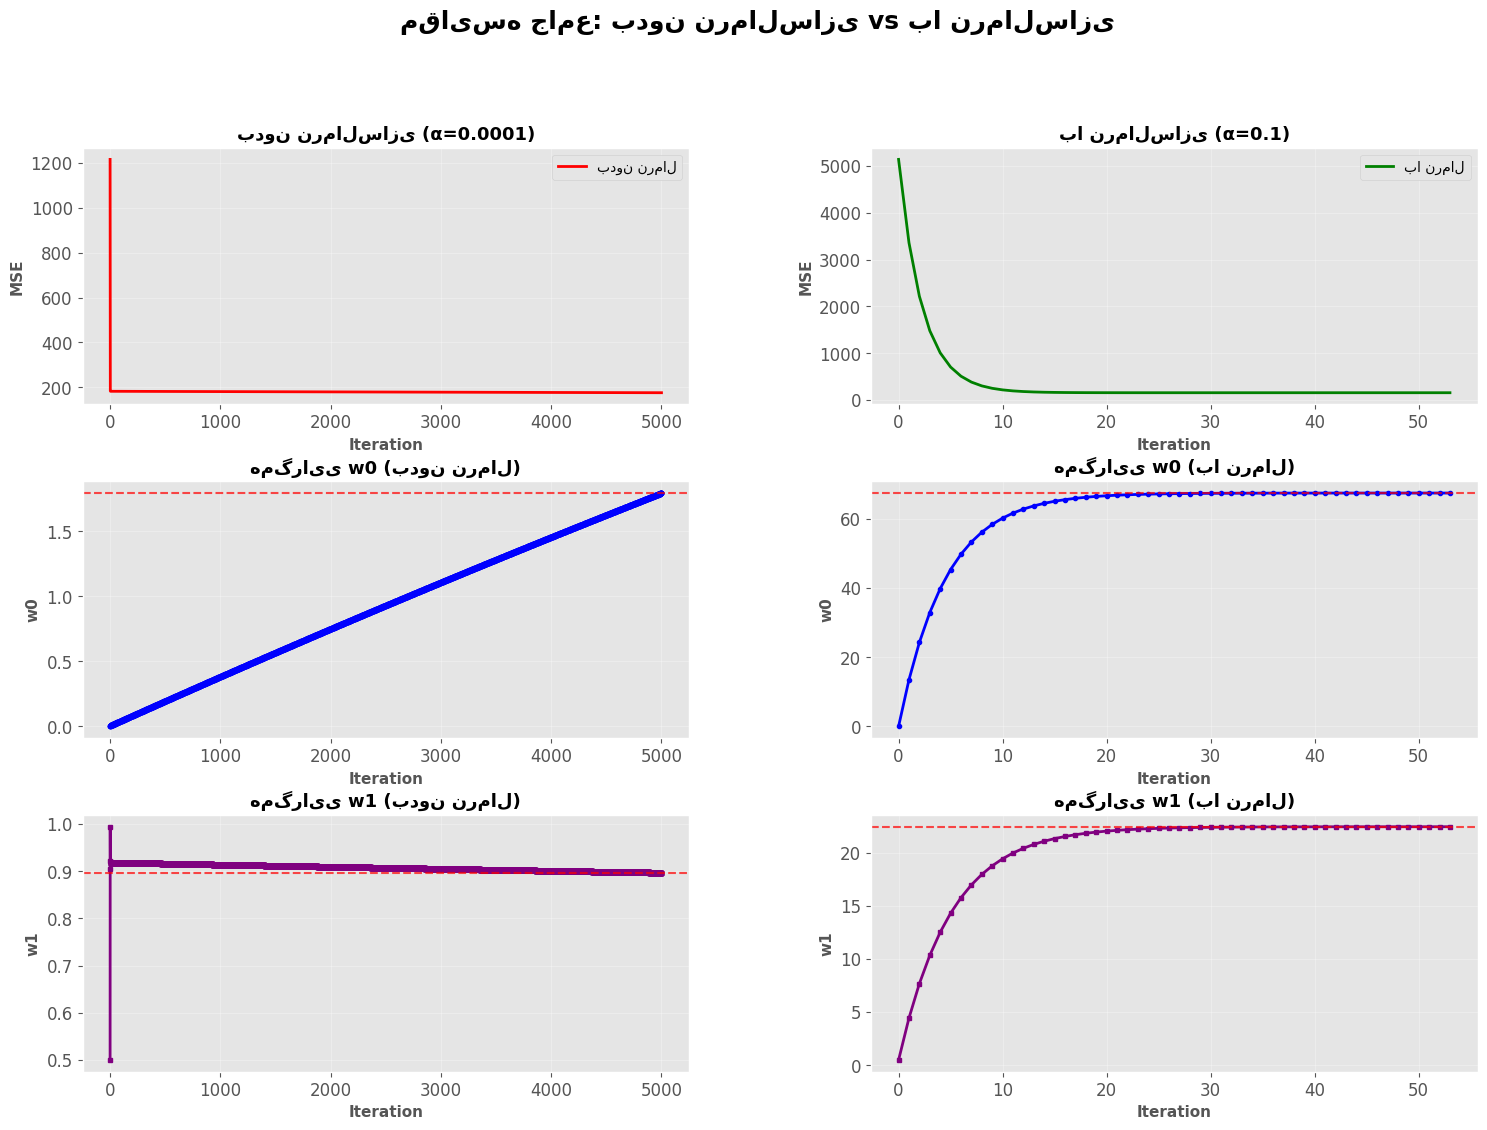


📊 خلاصه مقایسه:

🔴 بدون نرمال‌سازی (α=0.0001):
   • تعداد iterations: 5000
   • MSE نهایی: 175.90
   • w0 نهایی: 1.7943
   • w1 نهایی: 0.8969

🟢 با نرمال‌سازی (α=0.1):
   • تعداد iterations: 53
   • MSE نهایی: 155.48
   • w0 نهایی: 67.4994
   • w1 نهایی: 22.4236

✨ بهبودها:
   • سرعت: 94.3× سریع‌تر
   • نرخ یادگیری: 1000× بزرگتر
   • همگرایی: پایدارتر و سریع‌تر


In [ ]:
#  مقایسه جامع: بدون نرمال vs با نرمال
fig = plt.figure(figsize=(18, 12))

# تقسیم‌بندی: 3 ردیف × 2 ستون
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# ===== ردیف 1: همگرایی MSE =====
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(history_2d['mse'], linewidth=2, color='red', label='بدون نرمال')
ax1.set_xlabel('Iteration', fontsize=11, fontweight='bold')
ax1.set_ylabel('MSE', fontsize=11, fontweight='bold')
ax1.set_title('بدون نرمال‌سازی (α=0.0001)', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(history_norm['mse'], linewidth=2, color='green', label='با نرمال')
ax2.set_xlabel('Iteration', fontsize=11, fontweight='bold')
ax2.set_ylabel('MSE', fontsize=11, fontweight='bold')
ax2.set_title('با نرمال‌سازی (α=0.1)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# ===== ردیف 2: همگرایی w0 =====
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(history_2d['w0'], linewidth=2, color='blue', marker='o', markersize=3)
ax3.axhline(y=w_final[0], color='red', linestyle='--', alpha=0.7)
ax3.set_xlabel('Iteration', fontsize=11, fontweight='bold')
ax3.set_ylabel('w0', fontsize=11, fontweight='bold')
ax3.set_title(f'همگرایی w0 (بدون نرمال)', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3)

ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(history_norm['w0'], linewidth=2, color='blue', marker='o', markersize=3)
ax4.axhline(y=w_final_norm[0], color='red', linestyle='--', alpha=0.7)
ax4.set_xlabel('Iteration', fontsize=11, fontweight='bold')
ax4.set_ylabel('w0', fontsize=11, fontweight='bold')
ax4.set_title(f'همگرایی w0 (با نرمال)', fontsize=13, fontweight='bold')
ax4.grid(True, alpha=0.3)

# ===== ردیف 3: همگرایی w1 =====
ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(history_2d['w1'], linewidth=2, color='purple', marker='s', markersize=3)
ax5.axhline(y=w_final[1], color='red', linestyle='--', alpha=0.7)
ax5.set_xlabel('Iteration', fontsize=11, fontweight='bold')
ax5.set_ylabel('w1', fontsize=11, fontweight='bold')
ax5.set_title(f'همگرایی w1 (بدون نرمال)', fontsize=13, fontweight='bold')
ax5.grid(True, alpha=0.3)

ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(history_norm['w1'], linewidth=2, color='purple', marker='s', markersize=3)
ax6.axhline(y=w_final_norm[1], color='red', linestyle='--', alpha=0.7)
ax6.set_xlabel('Iteration', fontsize=11, fontweight='bold')
ax6.set_ylabel('w1', fontsize=11, fontweight='bold')
ax6.set_title(f'همگرایی w1 (با نرمال)', fontsize=13, fontweight='bold')
ax6.grid(True, alpha=0.3)

# عنوان کلی
fig.suptitle('مقایسه جامع: بدون نرمال‌سازی vs با نرمال‌سازی',
            fontsize=18, fontweight='bold', y=0.995)

plt.show()

# خلاصه آماری
print("\n" + "="*70)
print("📊 خلاصه مقایسه:")
print("="*70)
print(f"\n🔴 بدون نرمال‌سازی (α=0.0001):")
print(f"   • تعداد iterations: {len(history_2d['mse'])-1}")
print(f"   • MSE نهایی: {history_2d['mse'][-1]:.2f}")
print(f"   • w0 نهایی: {w_final[0]:.4f}")
print(f"   • w1 نهایی: {w_final[1]:.4f}")

print(f"\n🟢 با نرمال‌سازی (α=0.1):")
print(f"   • تعداد iterations: {len(history_norm['mse'])-1}")
print(f"   • MSE نهایی: {history_norm['mse'][-1]:.2f}")
print(f"   • w0 نهایی: {w_final_norm[0]:.4f}")
print(f"   • w1 نهایی: {w_final_norm[1]:.4f}")

print(f"\n✨ بهبودها:")
print(f"   • سرعت: {(len(history_2d['mse'])-1)/(len(history_norm['mse'])-1):.1f}× سریع‌تر")
print(f"   • نرخ یادگیری: {0.1/0.0001:.0f}× بزرگتر")
print(f"   • همگرایی: {'پایدارتر و سریع‌تر' if len(history_norm['mse']) < len(history_2d['mse']) else 'یکسان'}")
print("="*70)

/tmp/ipython-input-556590863.py:109: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


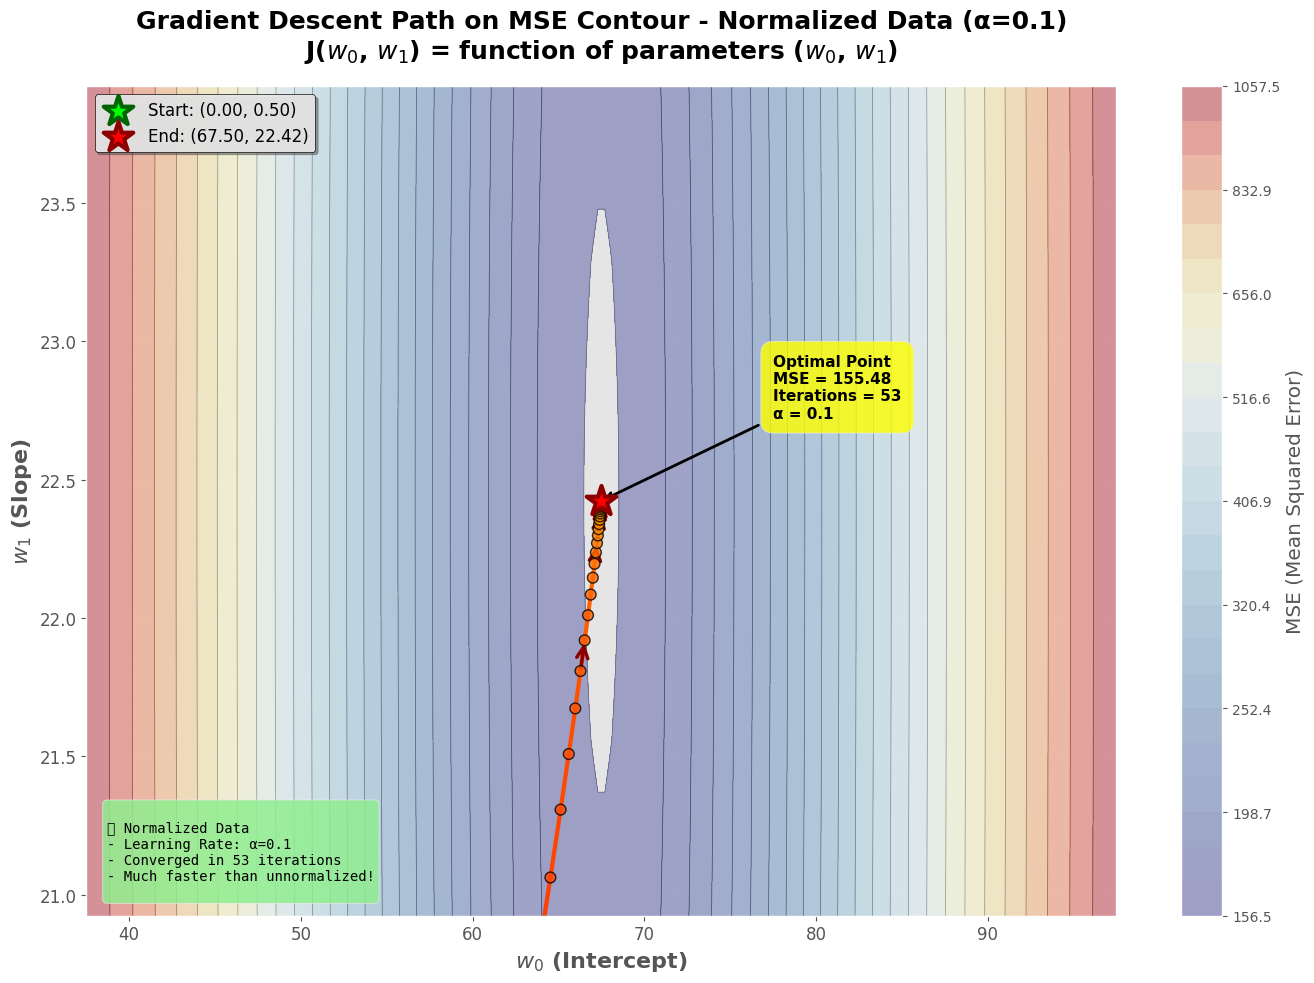

✅ نمودار Contour حرفه‌ای برای داده نرمال رسم شد!

📊 تحلیل مسیر (داده نرمال):
   • نقطه شروع: w0=0.00, w1=0.50
   • نقطه پایان: w0=67.50, w1=22.42
   • تغییر w0: 67.50
   • تغییر w1: 21.92
   • تعداد گام: 53
   • MSE نهایی: 155.48
   • Learning Rate: α=0.1


In [ ]:
# نمودار Contour
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.collections import LineCollection

# ساخت شبکه دقیق‌تر (محدوده باید متناسب با داده نرمال باشه)
w0_range_norm = np.linspace(w_final_norm[0]-30, w_final_norm[0]+30, 150)
w1_range_norm = np.linspace(w_final_norm[1]-1.5, w_final_norm[1]+1.5, 150)
W0_norm, W1_norm = np.meshgrid(w0_range_norm, w1_range_norm)

# محاسبه MSE برای داده نرمال
MSE_norm = np.zeros_like(W0_norm)
for i in range(W0_norm.shape[0]):
    for j in range(W0_norm.shape[1]):
        y_pred = W0_norm[i, j] + W1_norm[i, j] * x_normalized  # ⭐ داده نرمال
        MSE_norm[i, j] = np.mean((y - y_pred)**2)

# رسم
fig, ax = plt.subplots(figsize=(14, 10))

# Contour با رنگ‌بندی زیبا
levels = np.logspace(np.log10(MSE_norm.min()+1), np.log10(MSE_norm.max()), 25)
contourf = ax.contourf(W0_norm, W1_norm, MSE_norm, levels=levels,
                       cmap='RdYlBu_r', alpha=0.4)
contour = ax.contour(W0_norm, W1_norm, MSE_norm, levels=levels,
                     colors='black', linewidths=0.5, alpha=0.4)

# Colorbar
cbar = plt.colorbar(contourf, ax=ax, label='MSE (Mean Squared Error)')
cbar.ax.tick_params(labelsize=10)

# مسیر گرادیان کاهشی (داده نرمال)
path_w0_norm = history_norm['w0']
path_w1_norm = history_norm['w1']

# رسم مسیر با گرادیان رنگی
points_norm = np.array([path_w0_norm, path_w1_norm]).T.reshape(-1, 1, 2)
segments_norm = np.concatenate([points_norm[:-1], points_norm[1:]], axis=1)

lc_norm = LineCollection(segments_norm, cmap='autumn', linewidths=3)
lc_norm.set_array(np.arange(len(path_w0_norm)))
line_norm = ax.add_collection(lc_norm)

# نقاط روی مسیر
scatter = ax.scatter(path_w0_norm, path_w1_norm, c=range(len(path_w0_norm)),
                    cmap='autumn', s=60, edgecolors='black',
                    linewidth=1, zorder=5, alpha=0.8)

# نقطه شروع (ستاره سبز)
ax.scatter(path_w0_norm[0], path_w1_norm[0], c='lime', s=500, marker='*',
          edgecolors='darkgreen', linewidth=3, zorder=10,
          label=f'Start: ({path_w0_norm[0]:.2f}, {path_w1_norm[0]:.2f})')

# نقطه پایان (ستاره قرمز)
ax.scatter(path_w0_norm[-1], path_w1_norm[-1], c='red', s=500, marker='*',
          edgecolors='darkred', linewidth=3, zorder=10,
          label=f'End: ({path_w0_norm[-1]:.2f}, {path_w1_norm[-1]:.2f})')

# فلش‌های جهت
step = max(1, len(path_w0_norm)//8)
for i in range(0, len(path_w0_norm)-1, step):
    ax.annotate('', xy=(path_w0_norm[i+1], path_w1_norm[i+1]),
                xytext=(path_w0_norm[i], path_w1_norm[i]),
                arrowprops=dict(arrowstyle='->', color='darkred',
                              lw=2.5, mutation_scale=20))

# عنوان و برچسب‌ها
ax.set_xlabel('$w_0$ (Intercept)', fontsize=16, fontweight='bold')
ax.set_ylabel('$w_1$ (Slope)', fontsize=16, fontweight='bold')
ax.set_title('Gradient Descent Path on MSE Contour - Normalized Data (α=0.1)\n' +
            f'J($w_0$, $w_1$) = function of parameters ($w_0$, $w_1$)',
            fontsize=18, fontweight='bold', pad=20)

# راهنما
ax.legend(fontsize=12, loc='upper left', framealpha=0.95,
         edgecolor='black', fancybox=True, shadow=True)

# شبکه
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)

# محدوده محورها
ax.set_xlim([w0_range_norm.min(), w0_range_norm.max()])
ax.set_ylim([w1_range_norm.min(), w1_range_norm.max()])

# آنوتیشن برای نقطه بهینه
optimal_position = (path_w0_norm[-1], path_w1_norm[-1])
text_offset = (10, 0.3) if path_w1_norm[-1] < w1_range_norm.max() - 0.5 else (-15, -0.3)

ax.annotate(f'Optimal Point\nMSE = {history_norm["mse"][-1]:.2f}\n' +
           f'Iterations = {len(path_w0_norm)-1}\nα = 0.1',
           xy=optimal_position,
           xytext=(optimal_position[0]+text_offset[0], optimal_position[1]+text_offset[1]),
           fontsize=11, fontweight='bold',
           bbox=dict(boxstyle='round,pad=0.8', facecolor='yellow', alpha=0.8),
           arrowprops=dict(arrowstyle='->', lw=2, color='black'))

# اضافه کردن توضیحات در گوشه
textstr = f'''
✨ Normalized Data
- Learning Rate: α=0.1
- Converged in {len(path_w0_norm)-1} iterations
- Much faster than unnormalized!
'''
props = dict(boxstyle='round', facecolor='lightgreen', alpha=0.85)
ax.text(0.02, 0.02, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='bottom', bbox=props, family='monospace')

plt.tight_layout()
plt.show()

print("✅ نمودار Contour حرفه‌ای برای داده نرمال رسم شد!")
print(f"\n📊 تحلیل مسیر (داده نرمال):")
print(f"   • نقطه شروع: w0={path_w0_norm[0]:.2f}, w1={path_w1_norm[0]:.2f}")
print(f"   • نقطه پایان: w0={path_w0_norm[-1]:.2f}, w1={path_w1_norm[-1]:.2f}")
print(f"   • تغییر w0: {path_w0_norm[-1]-path_w0_norm[0]:.2f}")
print(f"   • تغییر w1: {path_w1_norm[-1]-path_w1_norm[0]:.2f}")
print(f"   • تعداد گام: {len(path_w0_norm)-1}")
print(f"   • MSE نهایی: {history_norm['mse'][-1]:.2f}")
print(f"   • Learning Rate: α=0.1")